In [ ]:
# This file is used to compare the variance of log mean fitness with different reproduction method: amitosis, mitosis, sexual (selfing
# and random mating) at diffrent frequency (Every 1/10/60/100 Generation). The reason to compare the variance is to investigate
# the intensity of selection (because selection works on variance). 
# The data used by this file can be found in the following folder：
# "F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data"

In [1]:
import numpy as np
import scipy.spatial as spa
import random
import pandas as pd 
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.linalg import hadamard
import itertools as it 
import scipy.stats as stat
import scipy.integrate as integrate
import math
import argparse
import os

In [2]:
generation_list = []

for i in range(10001):
    generation_list.append(10*i)
    
print(len(generation_list))

10001


In [3]:
# Amitosis
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Amitosis")

In [4]:
amito_file = ['Fit_Amito_5_V.csv', 'Fit_Amito_10_V.csv', 'Fit_Amito_20_V.csv', 'Fit_Amito_50_V.csv']

amito_var = []

for i in amito_file:
    amito = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(amito.varlog_Fit,dtype=float)))

    amito_var.append(var)

In [5]:
# Mitosis
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Mitosis")

In [6]:
mito_file = ['Fit_Mito_5_V.csv', 'Fit_Mito_10_V.csv', 'Fit_Mito_20_V.csv', 'Fit_Mito_50_V.csv']

mito_var = []

for i in mito_file:
    mito = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(mito.varlog_Fit,dtype=float)))

    mito_var.append(var)

In [7]:
# RM_Every 1G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Random Mating_Every 1G")

In [8]:
rm1_file = ['Fit_RM_5_E1_V.csv', 'Fit_RM_10_E1_V.csv', 'Fit_RM_20_E1_V.csv', 'Fit_RM_50_E1_V.csv']


rm1_var = []

for i in rm1_file:
    rm1 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(rm1.varlog_Fit,dtype=float)))

    rm1_var.append(var)

In [9]:
# RM_Every 10G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Random Mating_Every 10G")

In [10]:
# rm10_file = ['Fit_RM_5_E10_V.csv', 'Fit_RM_10_E10_V.csv', 'Fit_RM_20_E10_V.csv', 'Fit_RM_50_E10_V.csv']
rm10_file = ['Fit_RM_5_E10_V.csv', 'Fit_RM_10_E10_V.csv', 'Fit_RM_20_E10_V.csv', 'Fit_RM_50_E10_V.csv']

rm10_var = []

for i in rm10_file:
    rm10 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(rm10.varlog_Fit,dtype=float)))

    rm10_var.append(var)

In [11]:
# RM_Every 60G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Random Mating_Every 60G")

In [12]:
rm60_file = ['Fit_RM_5_E60_V.csv', 'Fit_RM_10_E60_V.csv', 'Fit_RM_20_E60_V.csv', 'Fit_RM_50_E60_V.csv']

rm60_var = []

for i in rm60_file:
    rm60 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(rm60.varlog_Fit,dtype=float)))

    rm60_var.append(var)

In [24]:
# RM_Every 100G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Random Mating_Every 100G")

In [25]:
rm100_file = ['Fit_RM_5_E100_V.csv', 'Fit_RM_10_E100_V.csv', 'Fit_RM_20_E100_V.csv', 'Fit_RM_50_E100_V.csv']

rm100_var = []

for i in rm100_file:
    rm100 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(rm100.varlog_Fit,dtype=float)))

    rm100_var.append(var)

In [15]:
# SF_Every 1G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Selfing_Every 1G")

In [16]:
sf1_file = ['Fit_SF_5_E1_V.csv', 'Fit_SF_10_E1_V.csv', 'Fit_SF_20_E1_V.csv', 'Fit_SF_50_E1_V.csv']

sf1_var = []

for i in sf1_file:
    sf1 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(sf1.varlog_Fit,dtype=float)))

    sf1_var.append(var)

In [17]:
# SF_Every 10G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Selfing_Every 10G")

In [18]:
sf10_file = ['Fit_SF_5_E10_V.csv', 'Fit_SF_10_E10_V.csv', 'Fit_SF_20_E10_V.csv', 'Fit_SF_50_E10_V.csv']

sf10_var = []

for i in sf10_file:
    sf10 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(sf10.varlog_Fit,dtype=float)))

    sf10_var.append(var)

In [19]:
# SF_Every 60G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Selfing_Every 60G")

In [20]:
sf60_file = ['Fit_SF_5_E60_V.csv', 'Fit_SF_10_E60_V.csv', 'Fit_SF_20_E60_V.csv', 'Fit_SF_50_E60_V.csv']

sf60_var = []

for i in sf60_file:
    sf60 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(sf60.varlog_Fit,dtype=float)))

    sf60_var.append(var)

In [21]:
# SF_Every 100G
os.chdir(r"F:\Prof. Azevedo\Simulation of Ciliate Evolution\1231_Comparison of Variance of Mito, Amito and Sex at Diff Freq_MUL_100K\Data\Selfing_Every 100G")

In [22]:
sf100_file = ['Fit_SF_5_E100_V.csv', 'Fit_SF_10_E100_V.csv', 'Fit_SF_20_E100_V.csv', 'Fit_SF_50_E100_V.csv']

sf100_var = []

for i in sf100_file:
    sf100 = pd.read_csv(i,dtype=str)
    
    var = []
    var.extend(list(pd.Series(sf100.varlog_Fit,dtype=float)))

    sf100_var.append(var)

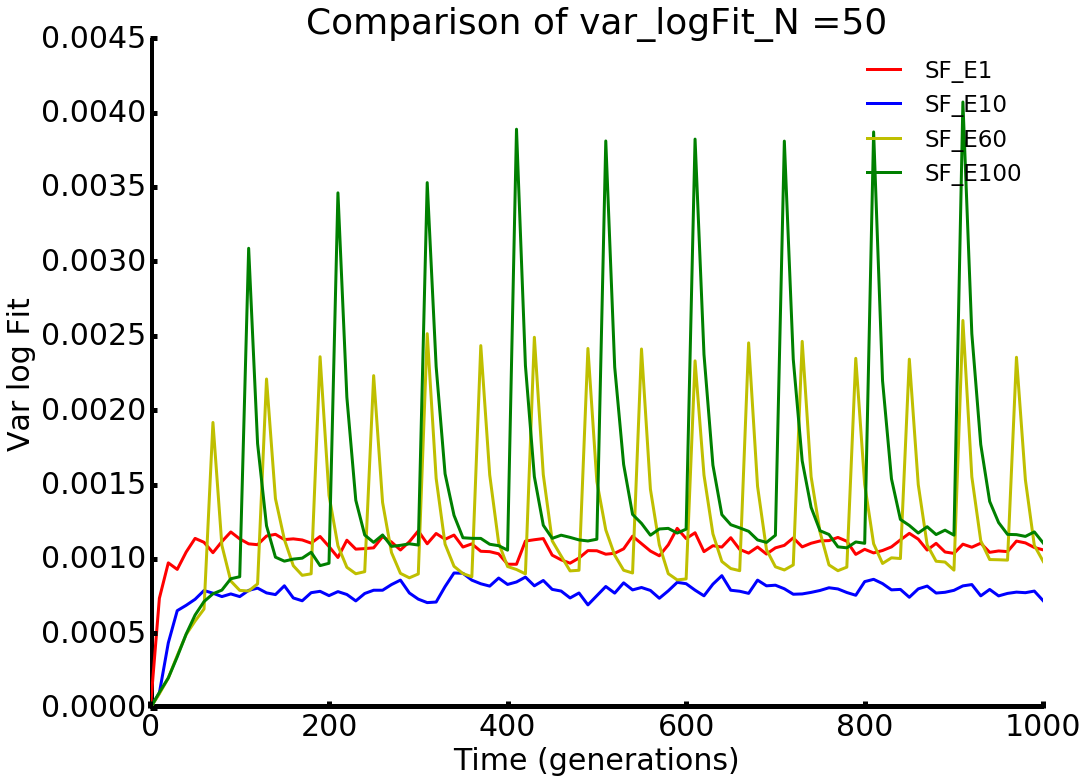

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

plt.figure(figsize=(16,12))

t = generation_list[:101]
a = amito_var[3][:101]
b = mito_var[3][:101]
c = sf1_var[3][:101]
d = rm1_var[3][:101]
e = sf10_var[3][:101]
f = rm10_var[3][:101]
g = sf60_var[3][:101]
h = rm60_var[3][:101]
i = sf100_var[3][:101]
j = rm100_var[3][:101]


plt.title('Comparison of var_logFit_N =50')
plt.xlabel('Time (generations)')
plt.ylabel('Var log Fit')
# plt.legend(['N =1', 'N =10', 'N =100', 'N =1000' ])
plt.rcParams.update({'font.size': 30})


# plt.show()
ax = plt.subplot(111)
ax.axhline(linewidth=8, color ='black')       
ax.axvline(linewidth=8, color = 'black')        

# plt.plot(t,a,'r', label = 'Amito', ls = 'solid',linewidth=3.0) # plotting t,a separately 
# plt.plot(t,b,'b', label = 'Mito', ls= 'dashdot', linewidth=3.0) # plotting t,b separately 
plt.plot(t,c,'r', label = 'SF_E1', ls = 'solid', linewidth=3.0) # plotting t,c separately 
# plt.plot(t,d,'y', label = 'RM_E1',ls = 'solid', linewidth=3.0)
plt.plot(t,e,'b', label = 'SF_E10', ls = 'solid', linewidth=3.0)
# plt.plot(t,f,'y', label = 'RM_E10',ls= 'solid', linewidth=3.0)
plt.plot(t,g,'y', label = 'SF_E60',ls = 'solid', linewidth=3.0)
# plt.plot(t,h,'y', label = 'RM_E60',ls = 'solid', linewidth=3.0)
plt.plot(t,i,'g', label = 'SF_E100', ls = 'solid', linewidth=3.0)
# plt.plot(t,j,'y', label = 'RM_E100',ls= 'solid', linewidth=3.0)


# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

ax.xaxis.set_tick_params(width=5, length =7)
ax.yaxis.set_tick_params(width=5, length =7)

# plt.legend(loc='upper right', frameon=False)
plt.legend(loc='upper right', frameon=False, prop={'size':23})

# plt.savefig('1', dpi=300, bbox_inches='tight')

plt.show()